# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [179]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [46]:
#Generating dataframe
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

In [47]:
#Data shows no irregularites, evaluating it by visual inspection as it is only 10 rows. 
student_data.head()


,Age,Tardies
0,17,10
1,51,1
2,27,5
3,21,9
4,36,4


Draw a dispersion diagram (scatter plot) for the data.

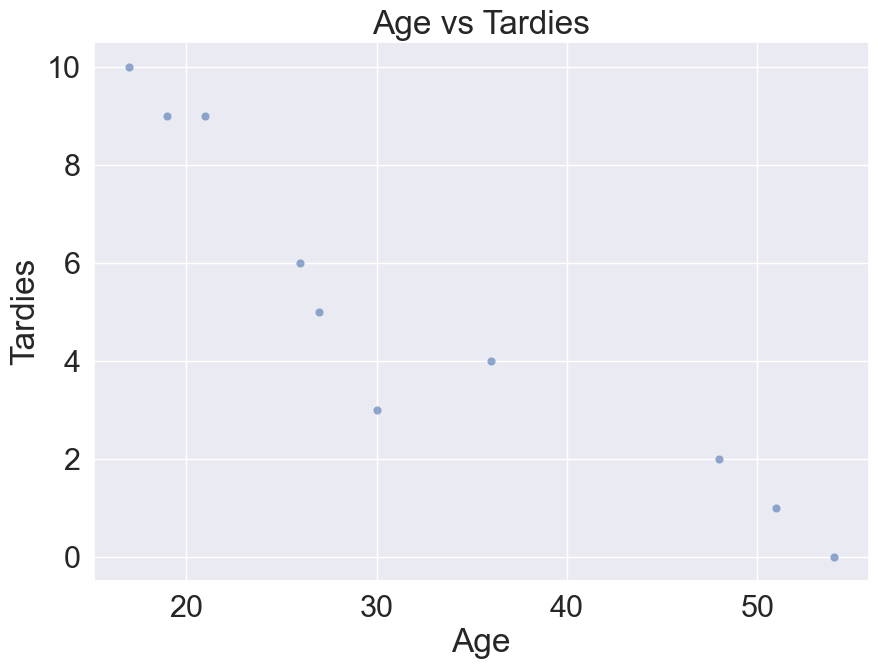

In [48]:
plt.figure(figsize=(10, 7))

sns.set_style('darkgrid')
sns.set(font_scale = 2)
# hue/style by categorical column
sns.scatterplot(
    x='Age',
    y='Tardies',
    data=student_data,
    s=40,
    alpha=0.6
).set_title('Age vs Tardies')

plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

Yes, the trend shows a linear decrease of the tardies as age increase. The initial hypothesis is supported by the visual inspection of the data, but it certainly needs to be supported by statistical correlation. 

1. The correlation of the data will be tested by the pearson's correlation, that will give information about the linearity of the trend. 

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [49]:
#Covariance: The covariance can allows us to measure how the variables change with respect to each other. 
# It is calculated by the product of the diference of each value with the mean of the sample. 
student_data.cov()

,Age,Tardies
Age,187.655556,-45.566667
Tardies,-45.566667,12.544444


- The covariance indicates shows a negative correlation between age and tardies, as shows by the visual inspection. This means that the variables are inversely proportional. 

In [14]:
#Correlation: will determine the linearity between the two variables. 
round(float(student_data["Age"].corr(student_data["Tardies"], method="pearson")),2)


-0.94

- The r value, or pearson's correlation coefficient shows a negative relation, which means that there is a negative slope, and close to 1 means that the variables behave linearly with respect to each other. 

Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

Linear Regression stats:
 slope:-0.2428207709159808
 intercept:12.888803363135768
 r:-0.9391626886887121
 std_err:0.03139728816158607


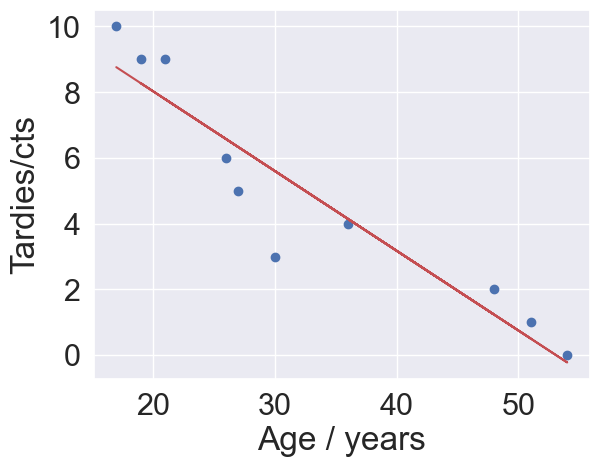

In [90]:
#Using linear regression, from scipy. 
#defining x and y 
x = student_data["Age"]
y = student_data["Tardies"]
slope, intercept, r, p, std_err = stats.linregress(x,y)
def linear_eq(x):
    return slope*x + intercept
model1 = list(map(linear_eq,x)) 
plt.scatter(x,y)
plt.plot(x,model1, color ='r')
plt.xlabel("Age / years")
plt.ylabel("Tardies/cts")
print(f"Linear Regression stats:\n slope:{slope}\n intercept:{intercept}\n r:{r}\n std_err:{std_err}")



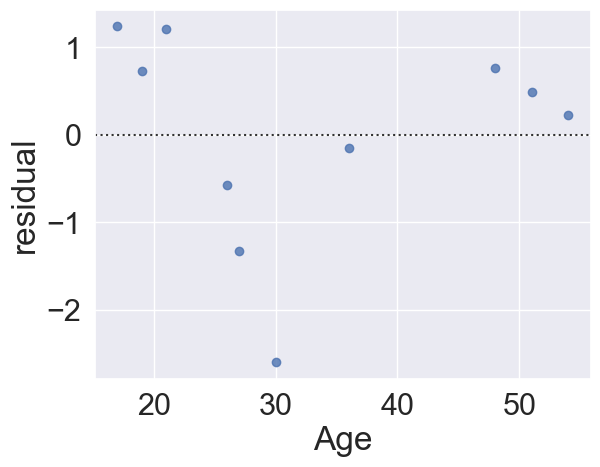

In [55]:
residuals = student_data.copy()
residuals["Fit"] = model1
residuals["residual"] = residuals["Tardies"]-residuals["Fit"]
residuals
sns.residplot(x="Age", y= "residual", data=residuals)
plt.show()

Residuals do not follow any specific trend, so there is no reproducible error associated in the fit. 


In [167]:
#Let's use scikit 
from sklearn.model_selection import train_test_split
#Data reshape
X = student_data[["Age"]] # Has to remain as either dataframe or a 2D array
y = student_data["Tardies"]
seed = 42
#Data needs to be split into sets for training
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = .1, shuffle=True,random_state = seed)

lr = LinearRegression()
model2 = lr.fit(X_train, y_train)
print(f"Linear Regression stats:\n intercept:{model2.intercept_}\n Slope:{model2.coef_} {model2.score(X_train,y_train)}")


Linear Regression stats:
 intercept:12.998046148120583
 Slope:[-0.24720878] 0.8464352274602036


Plot your regression model on your scatter plot.

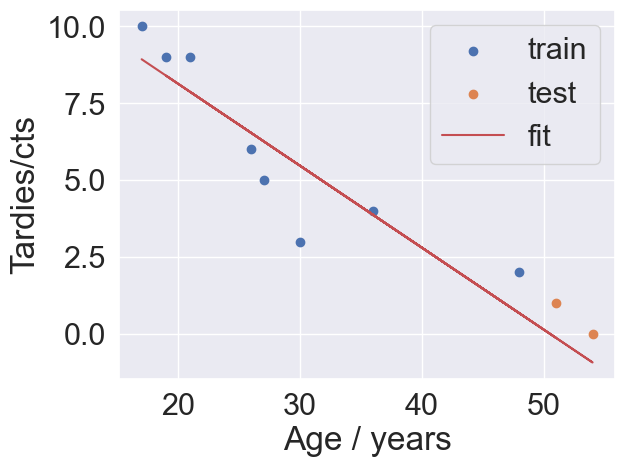

In [162]:
#Using linear regression, from scikit learn 

#Linear regression line made with the x values from random generated list
y_train_pred = model2.predict(X)

#plot the original set with the generated model
plt.scatter(X_train, y_train, label= "train")
plt.scatter(X_test, y_test, label= "test")
plt.plot(X, y_train_pred, color ='r', label = "fit")
plt.xlabel("Age / years")
plt.ylabel("Tardies/cts")
plt.legend()
plt.show()


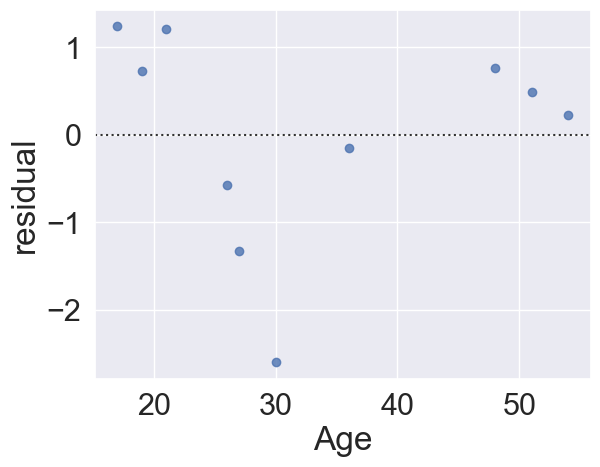

In [150]:
residuals2 = student_data.copy()
residuals2["y_target"] = student_data["Age"]*model2_reg.coef_ + model2_reg.intercept_
residuals2["residual"] = student_data["Tardies"]-residuals2["y_target"] 

sns.residplot(x="Age", y= "residual", data=residuals2)
plt.show()

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

- The data residuals do not show any specific trend which means that the fit was adequate. 
- The linearity of the fit is close to 1, which makes both variables highly correlated. 
- The hypothesis that tardiness and age are correlated is accepted, and the correlation shows that young people are late more than older students. 

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [168]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("../vehicles.csv")

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [169]:
#Target is CO2 Emission Grams/mile
#Features: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year
vehicles.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [188]:
# Approaching the problem with a multivariate regression. 

#Defining features and target
X_veh = vehicles[["Year", "Cylinders", "Fuel Barrels/Year", "Combined MPG", "Fuel Cost/Year"]]
y_veh = vehicles["CO2 Emission Grams/Mile"]

#Splitting data by train set and test sets. 

X_train, X_test, y_train, y_test = train_test_split(X_veh, y_veh, test_size=0.2, random_state=42)

#Calling the Linear regression estimator

lr = LinearRegression()

#Performing the fit
lr.fit(X_train, y_train)

#Summary of equation parameters: intercept and slope for each variable. 
print(lr.intercept_, lr.coef_)

755.693507314372 [-0.31558675  1.79402632 19.23102729 -2.9335732   0.03197145]


In [191]:
#Predict y 
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

#Calculating error associated

print("R2 square:")
print(f"train: {r2_score(y_train,y_train_pred)}, test: {r2_score(y_test,y_test_pred)}")
print("Mean square error:")
print(f"train: {mean_squared_error(y_train,y_train_pred)}, test: {mean_squared_error(y_test,y_test_pred)}")


R2 square:
train: 0.9812190180453002, test: 0.9794542628636334
Mean square error:
train: 266.5430924643347, test: 289.8277440813774


Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

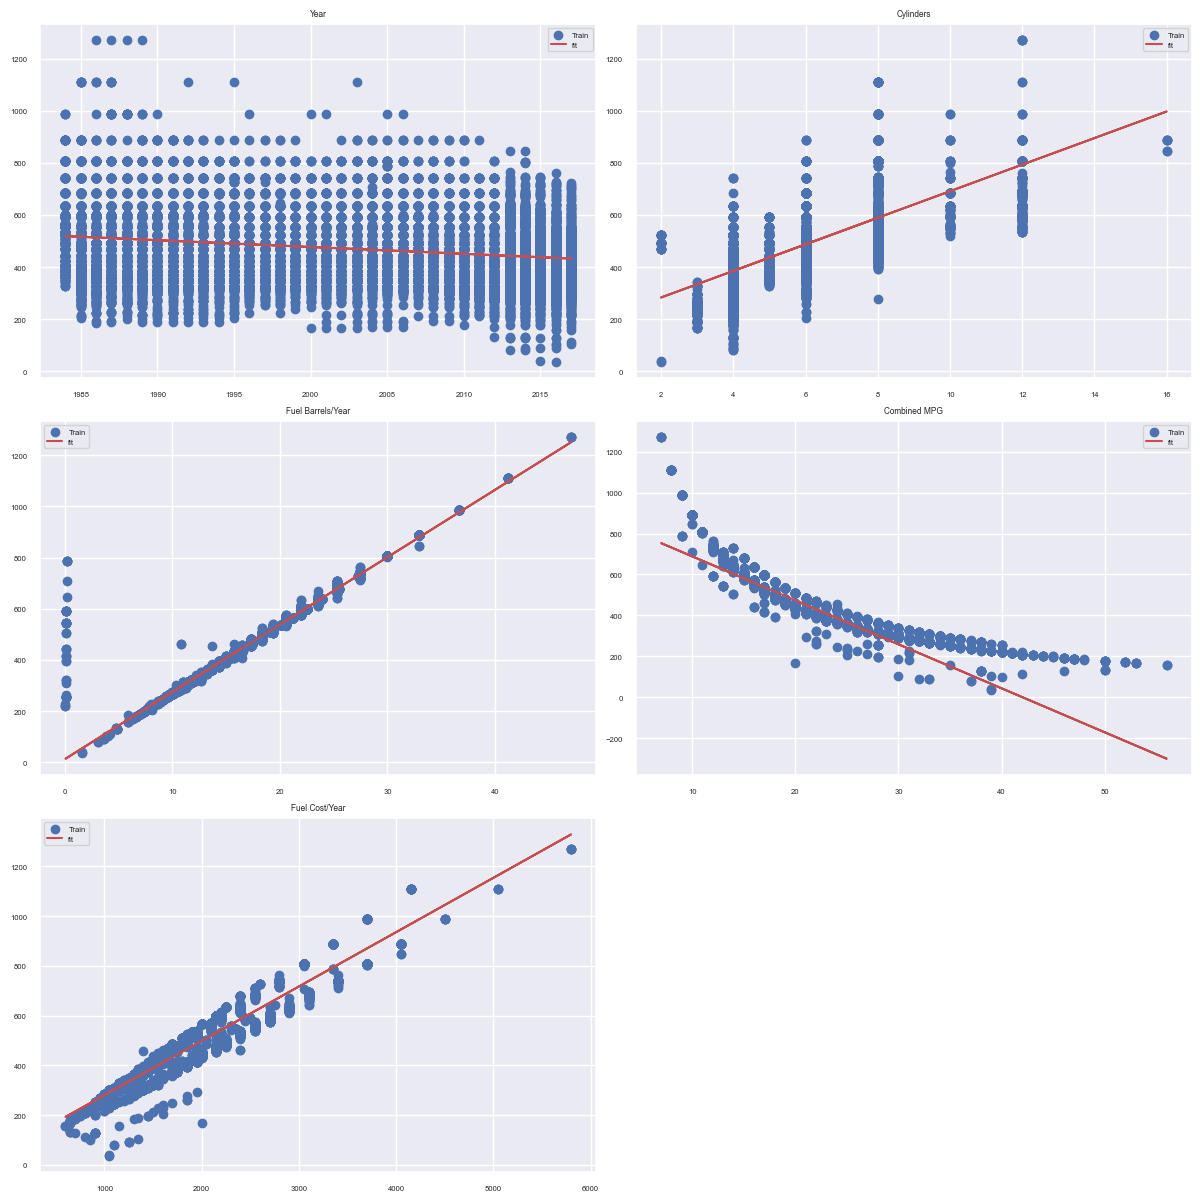

In [232]:
# Create a summary of the r2 scores and associated errors for each of the features. 
n_features = len(X_train.columns) 

#Generate a pandas dataframe for all columns. 
summary_fit = []

#Indications for plotting
plt.figure(figsize=(12, 12))
ax1 = plt.subplot2grid((3, 2), (0, 0))
ax2 = plt.subplot2grid((3, 2), (0, 1))
ax3 = plt.subplot2grid((3, 2), (1, 0))
ax4 = plt.subplot2grid((3, 2), (1, 1))
ax5 = plt.subplot2grid((3, 2), (2, 0))
axes = [ax1,ax2,ax3,ax4,ax5]


for i in range(n_features): #Which will iterate over all 5 columns
    ax = axes[i]

    # Select feature by name (assuming column names are informative)
    feat_name = X_train.columns[i]  # Use training data for column names
    feat_train = X_train[feat_name].to_numpy().reshape(-1,1)
    feat_test = X_test[feat_name].to_numpy().reshape(-1,1)
        
    #Linear fit model
    lr.fit(feat_train, y_train.values.reshape(-1, 1))

    #Predicting
    y_train_pred = lr.predict(feat_train)
    y_test_pred = lr.predict(feat_test)
    
    #metrics
    train_r2score = r2_score(y_train,y_train_pred)
    test_r2score = r2_score(y_test,y_test_pred)
    mse_train =mean_squared_error(y_train,y_train_pred)
    mse_test =mean_squared_error(y_test,y_test_pred)
    
    #Collection of metrics
    summary_fit.append([feat_name, train_r2score, test_r2score, mse_train, mse_test])
    
    ax.scatter(feat_train,y_train, label ="Train")
    ax.plot(feat_train,y_train_pred, 'r', label ="fit")
    ax.set_title(feat_name)
    ax.legend()
plt.tight_layout()
# Print or analyze scores as needed



In [ ]:
df_veh= pd.DataFrame(summary_fit, columns=["Feature", "Train Score", "Test Score", "Train MSE", "Test MSE"])
df_veh

,Feature,Train Score,Test Score,Train MSE,Test MSE
0,Year,0.048741,0.052116,13500.443084,13371.289934
1,Cylinders,0.565245,0.569502,6170.125726,6072.799776
2,Fuel Barrels/Year,0.973384,0.969282,377.745363,433.319638
3,Combined MPG,0.856455,0.863656,2037.215824,1923.338944
4,Fuel Cost/Year,0.867187,0.863778,1884.906824,1921.613637


- Based on the metrics, the R2 coefficients shows high linear correlation between the target: CO2 Emission Grams/Mile and (i) Fuel barrels per year , (ii) combined MPG and (iii) Fuel Cost per year. 
- Based on the graph, we see that although the R2 was high for the combined MPG, this does not represent the entirety of the data, which shows an exponential behavior rather than a linear. The mean square error wared us about this high differences, where the train MSE is much higher than that for the test.  
- THe relation to CO2 Emission Grams/Mile aligns best to the nummber of fuel barrels per year. The vehicle consuming more fuel will generate more CO2 emission. While there seems to be a trend as the cylinder number increases, this dataset should be treated differently as it first explains the differences by number of cylinders and each category varies slightly. 
- The fuel cost per year will also be related to the number of barrels per year, as the vehicle consums more, it will also emit more. 

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [237]:
data = {'Invited': [1,3,4,6,8,9,11,14], 'Attendees': [1,2,4,4,5,7,8,13]}
df = pd.DataFrame(data)
df["Absence"] = df["Invited"]-df["Attendees"]
df

,Invited,Attendees,Absence
0,1,1,0
1,3,2,1
2,4,4,0
3,6,4,2
4,8,5,3
5,9,7,2
6,11,8,3
7,14,13,1


Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

Text(0.5, 1.0, 'Invited vs Absences')

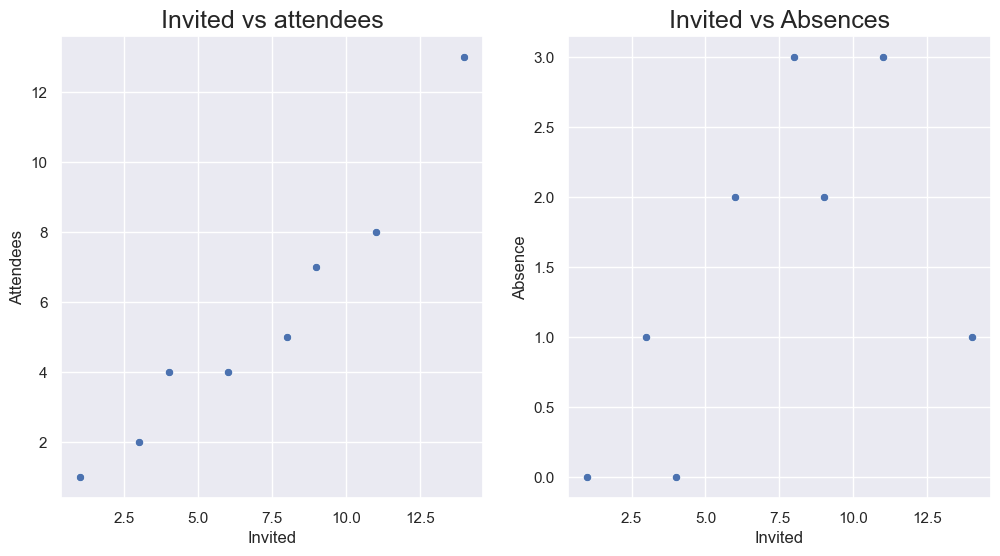

In [251]:
fig,ax = plt.subplots(1, 2, figsize =(12,6))
sns.set(font_scale=1.5)
sns.scatterplot(
    x='Invited',
    y='Attendees',
    data=df,
    ax = ax[0]
).set_title('Invited vs attendees')
sns.scatterplot(
    x='Invited',
    y='Absence',
    data=df,
    ax=ax[1]
).set_title('Invited vs Absences')

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

The data shows that with more invited people, more attendance. 

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

In [2]:
# Your response here.

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

*your explanation here*